Exact expectation value: -3.137782
   Shots        Mean         Std        Bias   Std*sqrt(N)
-------------------------------------------------------
     100   -3.114200    0.338577    0.023582        3.3858
     500   -3.148680    0.144296    0.010898        3.2266
    1000   -3.136920    0.108248    0.000862        3.4231
    5000   -3.140594    0.041887    0.002812        2.9618
   10000   -3.138020    0.031856    0.000238        3.1856
If Std*sqrt(N) is roughly constant → 1/sqrt(N) scaling confirmed ✓


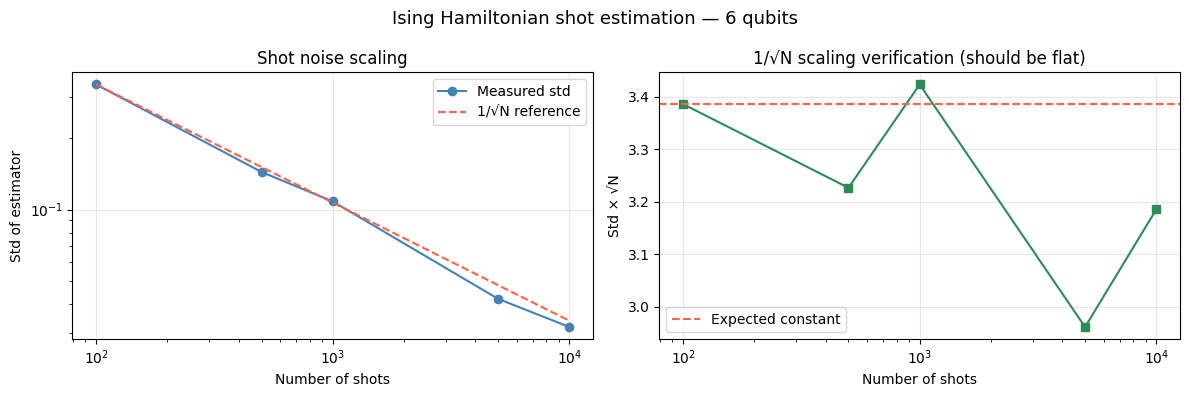

Done.


In [1]:
"""
Self-contained test for _estimate_expectation_shots

Ising Hamiltonian:
    H = sum_{k=1}^{N-1} X_k X_{k+1} + sum_{k=1}^{N} Z_k

Tests shot-based estimation against exact statevector value.
No external src/ imports needed — fully standalone.
"""

import numpy as np
import matplotlib.pyplot as plt
from qulacs import Observable, QuantumState, QuantumCircuit, DensityMatrix

# ─────────────────────────────────────────────────────────────
# 1. Build the Ising Hamiltonian
#    H = sum_{k} X_k X_{k+1}  +  sum_{k} Z_k
# ─────────────────────────────────────────────────────────────
def make_ising_hamiltonian(n_qubits: int) -> Observable:
    obs = Observable(n_qubits)
    # XX interaction terms
    for k in range(n_qubits - 1):
        obs.add_operator(1.0, f"X {k} X {k+1}")
    # Transverse Z field terms
    for k in range(n_qubits):
        obs.add_operator(1.0, f"Z {k}")
    return obs


# ─────────────────────────────────────────────────────────────
# 2. Shot-based estimator (mirrors _estimate_expectation_shots)
#    Parses terms directly from the Observable object.
#    Supports: XX (two-qubit X), Z (single-qubit Z)
# ─────────────────────────────────────────────────────────────
def estimate_expectation_shots(state, observable: Observable, n_qubits: int, n_shots: int) -> float:
    """
    Shot-based expectation value estimation.
    Parses Pauli terms from observable directly — no hardcoding.

    Pauli IDs in Qulacs: 0=I, 1=X, 2=Y, 3=Z
    """
    total    = 0.0
    n_terms  = observable.get_term_count()

    # Collect terms by measurement basis
    xx_terms = []   # (coeff, qi, qj)  — measure in X basis
    z_terms  = []   # (coeff, qi)      — measure in Z basis
    zz_terms = []   # (coeff, qi, qj)  — measure in Z basis
    skipped  = []

    for i in range(n_terms):
        term         = observable.get_term(i)
        coeff        = term.get_coef().real
        pauli_ids    = term.get_pauli_id_list()   # e.g. [1,1] for XX
        pauli_qubits = term.get_index_list()       # e.g. [0,1]

        if len(pauli_ids) == 2 and all(p == 1 for p in pauli_ids):
            # XX term
            xx_terms.append((coeff, pauli_qubits[0], pauli_qubits[1]))
        elif len(pauli_ids) == 1 and pauli_ids[0] == 3:
            # Z term
            z_terms.append((coeff, pauli_qubits[0]))
        elif len(pauli_ids) == 2 and all(p == 3 for p in pauli_ids):
            # ZZ term
            zz_terms.append((coeff, pauli_qubits[0], pauli_qubits[1]))
        else:
            skipped.append(i)
            print(f"[WARNING] Term {i} skipped — unsupported Pauli type: ids={pauli_ids}")

    # ── XX terms: rotate to X basis (apply H gate), then sample ──
    if xx_terms:
        x_state = QuantumState(n_qubits)
        x_state.load(state)
        rot = QuantumCircuit(n_qubits)
        for k in range(n_qubits):
            rot.add_H_gate(k)          # H rotates X eigenbasis → Z eigenbasis
        rot.update_quantum_state(x_state)

        x_samples = x_state.sampling(n_shots)
        x_energy  = 0.0
        for bitstring in x_samples:
            bits  = [(bitstring >> k) & 1 for k in range(n_qubits)]
            xvals = [1 - 2 * b for b in bits]   # |0>→+1, |1>→-1
            for coeff, qi, qj in xx_terms:
                x_energy += coeff * xvals[qi] * xvals[qj]
        total += x_energy / n_shots

    # ── Z and ZZ terms: sample directly in Z basis ────────────────
    if z_terms or zz_terms:
        z_samples = state.sampling(n_shots)
        z_energy  = 0.0
        for bitstring in z_samples:
            bits  = [(bitstring >> k) & 1 for k in range(n_qubits)]
            zvals = [1 - 2 * b for b in bits]   # |0>→+1, |1>→-1
            for coeff, qi in z_terms:
                z_energy += coeff * zvals[qi]
            for coeff, qi, qj in zz_terms:
                z_energy += coeff * zvals[qi] * zvals[qj]
        total += z_energy / n_shots

    return total


# ─────────────────────────────────────────────────────────────
# 3. Create a test state
#    Use a simple random-angle ansatz to get a non-trivial state
# ─────────────────────────────────────────────────────────────
def make_test_state(n_qubits: int, seed: int = 42) -> QuantumState:
    """Random Ry-CNOT ansatz — stands in for your VQE optimized state."""
    np.random.seed(seed)
    state   = QuantumState(n_qubits)
    circuit = QuantumCircuit(n_qubits)

    # Layer of Ry rotations
    for k in range(n_qubits):
        angle = np.random.uniform(0, 2 * np.pi)
        circuit.add_RY_gate(k, angle)

    # Layer of CNOT entanglers
    for k in range(n_qubits - 1):
        circuit.add_CNOT_gate(k, k + 1)

    # Second Ry layer
    for k in range(n_qubits):
        angle = np.random.uniform(0, 2 * np.pi)
        circuit.add_RY_gate(k, angle)

    circuit.update_quantum_state(state)
    return state


# ─────────────────────────────────────────────────────────────
# 4. Run the test
# ─────────────────────────────────────────────────────────────
N_QUBITS   = 6
N_TRIALS   = 200   # repeats per shot count for variance estimate
SHOT_COUNTS = [100, 500, 1000, 5000, 10000]

observable = make_ising_hamiltonian(N_QUBITS)
state      = make_test_state(N_QUBITS)

# ── Exact value (ground truth) ────────────────────────────────
exact = observable.get_expectation_value(state)
print(f"Exact expectation value: {exact:.6f}")
print(f"{'='*55}")
print(f"{'Shots':>8}  {'Mean':>10}  {'Std':>10}  {'Bias':>10}  {'Std*sqrt(N)':>12}")
print(f"{'-'*55}")

results = {}
for n_shots in SHOT_COUNTS:
    estimates = [
        estimate_expectation_shots(state, observable, N_QUBITS, n_shots)
        for _ in range(N_TRIALS)
    ]
    mean      = np.mean(estimates)
    std       = np.std(estimates)
    bias      = abs(mean - exact)
    std_sqrt_n = std * np.sqrt(n_shots)   # should be ~constant if 1/sqrt(N) scaling holds
    results[n_shots] = dict(mean=mean, std=std, bias=bias)
    print(f"{n_shots:>8}  {mean:>10.6f}  {std:>10.6f}  {bias:>10.6f}  {std_sqrt_n:>12.4f}")

print(f"{'='*55}")
print("If Std*sqrt(N) is roughly constant → 1/sqrt(N) scaling confirmed ✓")


# ─────────────────────────────────────────────────────────────
# 5. Plot: Std vs Shot count  (expect 1/sqrt(N) decay)
# ─────────────────────────────────────────────────────────────
shots_arr = np.array(SHOT_COUNTS)
stds_arr  = np.array([results[s]['std'] for s in SHOT_COUNTS])

# Fit 1/sqrt(N) reference curve
ref_scale = stds_arr[0] * np.sqrt(shots_arr[0])
ref_curve = ref_scale / np.sqrt(shots_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: std vs shots
axes[0].plot(shots_arr, stds_arr, 'o-', label='Measured std', color='steelblue')
axes[0].plot(shots_arr, ref_curve, '--', label='1/√N reference', color='tomato')
axes[0].set_xlabel('Number of shots')
axes[0].set_ylabel('Std of estimator')
axes[0].set_title('Shot noise scaling')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Right: std * sqrt(N) — should be flat
axes[1].plot(shots_arr, stds_arr * np.sqrt(shots_arr), 's-', color='seagreen')
axes[1].axhline(ref_scale, color='tomato', linestyle='--', label='Expected constant')
axes[1].set_xlabel('Number of shots')
axes[1].set_ylabel('Std × √N')
axes[1].set_title('1/√N scaling verification (should be flat)')
axes[1].legend()
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ising Hamiltonian shot estimation — {N_QUBITS} qubits', fontsize=13)
plt.tight_layout()
plt.show()
print("Done.")

In [2]:
observable

In [4]:
eigenvalues, _ = np.linalg.eigh(observable.get_matrix().toarray())
min_eigenvalue = np.min(eigenvalues)
print(f"Minimum eigenvalue of the Ising Hamiltonian: {min_eigenvalue:.6f}")

Minimum eigenvalue of the Ising Hamiltonian: -7.296230
